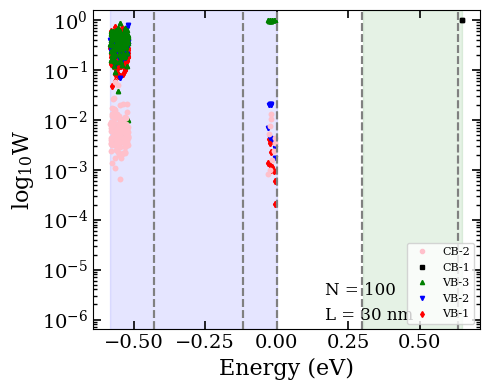

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh


import numpy as np
import matplotlib.pyplot as plt


# ======= PLOT SETTINGS =======
plt.rcParams.update({
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})
N = n_states = 100
L = 300

NUM_VB_2,sigma_v2 = 250, -0.55
NUM_VB_1, sigma_v1 = 20, 0
NUM_CB, sigma_c = 2, 0.65
num_states_vb = NUM_VB_2 + NUM_VB_1
num_states_cb = NUM_CB



bulk_energy = np.loadtxt("bulk_energy_o.dat")

color_list = ["r", "b", "g", "k", "pink"]
legend_list = ["VB-1", "VB-2", "VB-3", "CB-1", "CB-2"]
symbol_list = ["d", "v", "^", "s", "o"]



evals_vb = np.loadtxt(f"energies_nw_vb_{N}_o_numv2_{NUM_VB_2}_v2_{sigma_v2}_numv1_{NUM_VB_1}_v1_{sigma_v1}_numcb_{NUM_CB}_c_{sigma_c}.dat")[:num_states_vb][::-1]
evals_cb = np.loadtxt(f"energies_nw_cb_{N}_o_numv2_{NUM_VB_2}_v2_{sigma_v2}_numv1_{NUM_VB_1}_v1_{sigma_v1}_numcb_{NUM_CB}_c_{sigma_c}.dat")[:num_states_cb]

full_energy = np.concatenate((evals_vb, evals_cb))

overlap_vb = np.loadtxt(f"overlap_vb_N{N}_states{num_states_vb}_o_numv2_{NUM_VB_2}_v2_{sigma_v2}_numv1_{NUM_VB_1}_v1_{sigma_v1}_numcb_{NUM_CB}_c_{sigma_c}.dat")[::-1]
overlap_cb = np.loadtxt(f"overlap_cb_N{N}_states{num_states_cb}_o_numv2_{NUM_VB_2}_v2_{sigma_v2}_numv1_{NUM_VB_1}_v1_{sigma_v1}_numcb_{NUM_CB}_c_{sigma_c}.dat")


# bulk band summed over spin index
overlap_cb_spin_sum = np.array([
    overlap_cb[:, j] + overlap_cb[:, j + 1]
    for j in range(0, len(overlap_cb[0]), 2)
])

overlap_vb_spin_sum = np.array([
    overlap_vb[:, j] + overlap_vb[:, j + 1]
    for j in range(0, len(overlap_vb[0]), 2)
])

full_overlap_array = np.hstack((overlap_vb_spin_sum, overlap_cb_spin_sum))

saving_data = np.vstack((full_energy, full_overlap_array)).T
np.savetxt(f"energy_overlap_data_N{N}_o_numv2_{NUM_VB_2}_v2_{sigma_v2}_numv1_{NUM_VB_1}_v1_{sigma_v1}_numcb_{NUM_CB}_c_{sigma_c}.dat", saving_data)

# ---------------------------------------------------
# Figure
# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(5, 4))

# plots
for i in range(5):

    ax.plot(
        full_energy,
        full_overlap_array[i],
        symbol_list[i],
        label=legend_list[i],
        color=color_list[i],
        markersize=3
    )

# ---------------------------------------------------
# shaded regions
# ---------------------------------------------------

ax.axvspan(evals_vb[-1], 0,
           color='blue',
           alpha=0.10)

ax.axvspan(0.3, evals_cb[-1],
           color='green',
           alpha=0.10)

# ---------------------------------------------------
# labels
# ---------------------------------------------------

ax.set_xlabel("Energy (eV)", fontsize=16)
ax.set_ylabel(r"log$_{10}$W", fontsize=16)

# scales and limits
ax.set_yscale('log')

ax.set_ylim(10**-6.2, 10**0.2)
# ax.set_xlim(-0.2, 0.7)

# ---------------------------------------------------
# legend
# ---------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

ax.legend(handles[::-1],
          labels[::-1],
          frameon=True,
          loc='lower right',
          fontsize=8,
          ncol=1)

# ---------------------------------------------------
# text
# ---------------------------------------------------

ax.text(0.60, 0.15,

        f"N = {N}",
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top')

ax.text(0.60, 0.07,
        fr"L = {int(L/10)} nm",
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top')

# ---------------------------------------------------
# vertical guide lines
# ---------------------------------------------------

for i in bulk_energy:

    ax.axvline(x=i,
               linestyle='--',
               color='gray')

# ---------------------------------------------------
# Tick styling
# ---------------------------------------------------

# Enable minor ticks
ax.minorticks_on()

# Major ticks
ax.tick_params(axis='both',
               which='major',
               direction='in',
               top=True,
               right=True,
               length=6,
               width=1.2,
               labelsize=14)

# Minor ticks ONLY on y-axis (left/right)
ax.tick_params(axis='y',
               which='minor',
               direction='in',
               left=True,
               right=True,
               length=3,
               width=1.0)

# Disable x-axis minor ticks
ax.tick_params(axis='x',
               which='minor',
               bottom=False,
               top=False)

# ---------------------------------------------------
# grid
# ---------------------------------------------------

# ax.grid(alpha=0.3)

fig.tight_layout()

# save
fig.savefig(f"overlap_energy_log_scale_{N}.png", dpi=300)
fig.savefig(f"overlap_energy_log_scale_{N}.pdf")

plt.show()


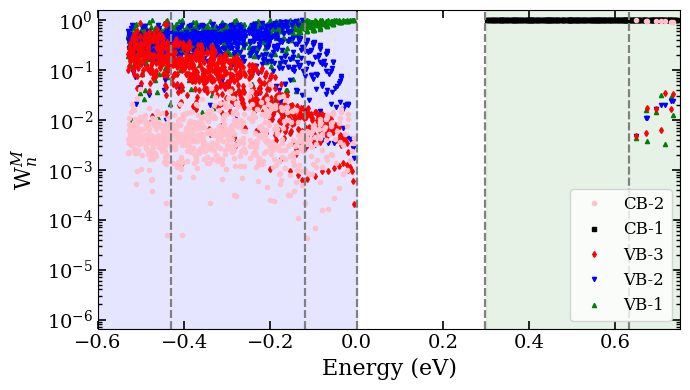

In [11]:
cb_levels = [0.3, 0.5, 0.65]

# =========================
# Load CB data
# =========================
all_cb_data = []

for cb in cb_levels:
    filename = f"energy_overlap_data_N100_o_numv2_2_v2_-0.1_numv1_20_v1_0_numcb_250_c_{cb}.dat"
    data = np.loadtxt(filename)
    all_cb_data.append(data)

# Stack all CB data
combined_cb_data = np.vstack(all_cb_data)
# print(combined_data[combined_data[:,0]>0])


vb_levels = [0]
# =========================
# Load VB data
# =========================
all_vb_data = []

for vb in vb_levels:
    filename = f"energy_overlap_data_N100_o_numv2_2_v2_-0.1_numv1_250_v1_{vb}_numcb_2_c_0.65.dat"
    data = np.loadtxt(filename)
    all_vb_data.append(data)

# Stack all VB data
combined_vb_data = np.vstack(all_vb_data)


vb_levels_2 = [-0.2, -0.3, -0.35, -0.4, -0.45, -0.5]#, -0.55]
# =========================
# Load VB data
# =========================
all_vb_data_2 = []

for vb in vb_levels_2:
    filename = f"energy_overlap_data_N100_o_numv2_250_v2_{vb}_numv1_20_v1_0_numcb_2_c_0.65.dat"
    data = np.loadtxt(filename)
    all_vb_data_2.append(data)

# Stack all VB data
combined_vb_data_2 = np.vstack(all_vb_data_2)




# # =========================
# # Stack CB + VB data together
# # =========================
combined_data = np.vstack([combined_cb_data, combined_vb_data, combined_vb_data_2])


# Sort by energy column
combined_data = combined_data[np.argsort(combined_data[:, 0])]



# Remove repeated energy values
rounded_energy = np.round(combined_data[:, 0], decimals=10)
_, unique_indices = np.unique(rounded_energy, return_index=True)

clean_data = combined_data[unique_indices]

# Sort again after removing duplicates
clean_data = clean_data[np.argsort(clean_data[:, 0])]

# Save final joined file
np.savetxt(
    f"overlap_data_N{N}.dat",
    clean_data,
    fmt="%.10e",
    header="Energy    MatrixElement"
)

# ---------------------------------------------------
# Figure
# ---------------------------------------------------

color_list = ["r", "b", "g", "k", "pink"]
legend_list = ["VB-1", "VB-2", "VB-3", "CB-1", "CB-2"]
symbol_list = ["d", "v", "^", "s", "o"]

fig, ax = plt.subplots(figsize=(7, 4))

# plots
for i in range(2,-1,-1):

    ax.plot(
        clean_data[:, 0],
        clean_data[:, i + 1],
        symbol_list[i],
        label=legend_list[abs(i-2)],
        color=color_list[i],
        markersize=3
    )


for i in range(3,5):

    ax.plot(
        clean_data[:, 0],
        clean_data[:, i + 1],
        symbol_list[i],
        label=legend_list[i],
        color=color_list[i],
        markersize=3
    )
# ---------------------------------------------------
# shaded regions
# ---------------------------------------------------

ax.axvspan(-0.6, 0, color='blue', alpha=0.1)
ax.axvspan(0.3, 0.75, color='green', alpha=0.1)

# ---------------------------------------------------
# labels
# ---------------------------------------------------

ax.set_xlabel("Energy (eV)", fontsize=16)
ax.set_ylabel(r"W$_n^M$", fontsize=16)

# scales and limits
ax.set_yscale('log')

ax.set_ylim(10**-6.2, 10**0.2)
ax.set_xlim(-0.6, 0.75)

# ---------------------------------------------------
# legend
# ---------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

ax.legend(handles[::-1],
          labels[::-1],
          frameon=True,
          loc='lower right',
          fontsize=12,
          ncol=1)

# ---------------------------------------------------
# text
# ---------------------------------------------------

# ax.text(0.60, 0.15,

#         f"N = {N}",
#         transform=ax.transAxes,
#         fontsize=12,
#         verticalalignment='top')

# ax.text(0.60, 0.07,
#         fr"L = {int(L/10)} nm",
#         transform=ax.transAxes,
#         fontsize=12,
#         verticalalignment='top')

# ---------------------------------------------------
# vertical guide lines
# ---------------------------------------------------

for i in bulk_energy:

    ax.axvline(x=i,
               linestyle='--',
               color='gray')

# ---------------------------------------------------
# Tick styling
# ---------------------------------------------------

# Enable minor ticks
ax.minorticks_on()

# Major ticks
ax.tick_params(axis='both',
               which='major',
               direction='in',
               top=True,
               right=True,
               length=6,
               width=1.2,
               labelsize=14)

# Minor ticks ONLY on y-axis (left/right)
ax.tick_params(axis='y',
               which='minor',
               direction='in',
               left=True,
               right=True,
               length=3,
               width=1.0)

# Disable x-axis minor ticks
ax.tick_params(axis='x',
               which='minor',
               bottom=False,
               top=False)

# ---------------------------------------------------
# grid
# ---------------------------------------------------

# ax.grid(alpha=0.3)

fig.tight_layout()

# save
fig.savefig(f"full_range_overlap_energy_log_scale_{N}.png", dpi=300)
fig.savefig(f"full_range_overlap_energy_log_scale_{N}.pdf")

plt.show()
